# Capstone EDA — Supervised-Learning-Readiness Notebook
## GA 5800 — Summer 2026

**Student:** *Yeoungeun Ra*  
**Dataset:** *selected_mod_data_slim.parquet*  
**Date submitted:** *YYYY-MM-DD*

---

This notebook is your scaffold for the 10-stage capstone. Each stage has:
- a markdown cell describing what to produce,
- empty code cells for your analysis,
- a markdown cell for your written interpretation.

You are **not** limited to the cells provided. Add code, markdown, and plots as needed.

### Before you begin
- Read the full assignment brief: `capstone_eda_supervised_readiness.pdf`.
- Set your random seed in the setup cell below.
- Treat the Stage 10 Data Card as a *living* document — fill it in as you complete each stage, not at the end.

### Submission reminders
- Every p-value must be paired with an **effect size**.
- Every plot must have a title, axis labels (with units), and a caption stating the takeaway.
- Notebook must execute top-to-bottom on a fresh kernel.
- Submit alongside `<lastname>_<firstname>_data_card.md` and `<lastname>_<firstname>_readiness_memo.pdf` as a single zipped folder.

---

## Setup

Imports, random seed, and data load.

In [3]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import (
    chi2_contingency, kruskal, mannwhitneyu, f_oneway,
    pointbiserialr, spearmanr, kendalltau, pearsonr,
)

# sklearn
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display + plot defaults
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
# Load the dataset
DATA_PATH = 'datasets/raw/selected_mod_data_slim.parquet'  # update this path
df = pd.read_parquet(DATA_PATH)

print(f'Shape: {df.shape}')
df.head()

Shape: (356448, 19)


,record_id,weight,cur_term_eff_dt,cur_term_xptn_dt,pol_state_eff_dt,row_xptn_dt,orgl_pol_eff_dt,vendor_year,risk_score1,mod140,mod140_year,ee,ncat,state,zip,zip4,qpid,pa_latitude,pa_longitude
0,CTH00002000706,2.680062,2019-10-18,2020-10-18,2019-10-18,2020-10-18,2019-10-18,2018,998.0,735.840532,2019,0.999995,0.0,CT,6611,2548,25005369,41.275661,-73.202757
1,CTH00002000706,2.680062,2020-10-18,2021-10-18,2020-11-04,2021-10-18,2019-10-18,2019,998.0,992.952935,2020,0.999993,0.0,CT,6611,2548,25005369,41.275661,-73.202757
2,CTH00002000706,2.680062,2021-10-18,2022-10-18,2022-01-14,2022-10-18,2019-10-18,2020,998.0,618.968214,2021,0.241094,0.0,CT,6611,2548,25005369,41.275661,-73.202757
3,CTH00002000707,2.680062,2019-11-03,2020-11-03,2019-11-03,2020-11-03,2019-11-03,2018,742.0,4314.604013,2019,0.999994,0.0,CT,6903,5134,24894066,41.122856,-73.529479
4,CTH00002000707,2.680062,2020-11-03,2021-11-03,2021-09-29,2021-11-03,2019-11-03,2019,742.0,2718.766590,2020,0.999993,0.0,CT,6903,5134,24894066,41.122856,-73.529479


---

## Stage 1 — Problem Framing & Target Definition  *(5 pts)*

**Produce in writing (no code required):**
- One-paragraph problem statement: what would a model predict, for whom, and why?
- Explicit target definition: variable name, type (binary / multiclass / continuous / count / ordinal), unit of observation, **time-of-prediction** (what is known *at prediction time* vs. observed afterward).
- Proposed primary evaluation metric **with justification** (why F1 vs. ROC-AUC vs. PR-AUC; why RMSE vs. MAE vs. MAPE) based on what you know of the problem at this early stage.
- Statement of single- vs. multi-target / multi-output problem based on what you know of the problem at this early stage.

### Your Stage 1 response

*Write your problem framing here.*

**Problem statement:**
This project aims to predict future non-catastrophe (NCAT) loss and pure premium for property insurance policy terms. The objective is to evaluate whether external vendor data can improve predictive performance beyond the current baseline model, mod140. Improved prediction accuracy can support better pricing, risk segmentation, underwriting decisions, and portfolio stability across states and time periods.

**Target definition:**
- Target variable: pure_premium = annualized NCAT loss   
- Problem type: Continuous regression
- Unit of observation: Property insurance policy term
- Pure premium concept: 
$$
\text{Pure Premium} = \frac{\text{Loss}}{\text{Exposure}}
$$
- Preferred modeling setup: Tweedie regression with exposure offset  
$$
\log(E(\text{NCAT})) = \log(\text{EE}) + f(X)
$$


**Time-of-prediction:**
Information available at policy effective date only; future claims information is excluded to avoid leakage.

**Proposed metric and justification:**
- Primary metric: Gini coefficient
- Reason: Insurance pricing focuses on risk ranking and separation of high-risk vs. low-risk policies.
- Additional metrics: Decile lift and calibration across exposure deciles to evaluate pricing accuracy and stability.

**Single- vs. multi-target:**
This is a single-target supervised regression problem because the model predicts one primary outcome: future NCAT loss / pure premium for each policy term.

---

## Stage 2 — Data Inventory & Schema Audit  *(7 pts)*

**Produce:**
- Shape, memory footprint, dtype table.
- A **semantic feature-type table** (one row per column): `name | pandas dtype | semantic type | role | notes`, where  
  `semantic type ∈ {continuous, count, ordinal, nominal, binary, datetime, text, identifier, geographic, other}`  
  `role ∈ {feature, target, identifier, metadata, leakage-suspect}`.
- A list of columns where pandas dtype disagrees with the semantic type (e.g., zip codes as `int64`) and your planned coercion.

This table seeds your final Data Card.

In [5]:
# Shape, memory, dtypes

print("Shape:", df.shape)

print("\nMemory Usage (MB):")
print(df.memory_usage(deep=True).sum() / 1024**2)

print("\nDtypes:")
display(df.dtypes.value_counts())

display(df.head())


Shape: (356448, 19)

Memory Usage (MB):
89.40311050415039

Dtypes:


float64           7
datetime64[ns]    5
Int64             3
object            2
Int32             2
Name: count, dtype: int64

,record_id,weight,cur_term_eff_dt,cur_term_xptn_dt,pol_state_eff_dt,row_xptn_dt,orgl_pol_eff_dt,vendor_year,risk_score1,mod140,mod140_year,ee,ncat,state,zip,zip4,qpid,pa_latitude,pa_longitude
0,CTH00002000706,2.680062,2019-10-18,2020-10-18,2019-10-18,2020-10-18,2019-10-18,2018,998.0,735.840532,2019,0.999995,0.0,CT,6611,2548,25005369,41.275661,-73.202757
1,CTH00002000706,2.680062,2020-10-18,2021-10-18,2020-11-04,2021-10-18,2019-10-18,2019,998.0,992.952935,2020,0.999993,0.0,CT,6611,2548,25005369,41.275661,-73.202757
2,CTH00002000706,2.680062,2021-10-18,2022-10-18,2022-01-14,2022-10-18,2019-10-18,2020,998.0,618.968214,2021,0.241094,0.0,CT,6611,2548,25005369,41.275661,-73.202757
3,CTH00002000707,2.680062,2019-11-03,2020-11-03,2019-11-03,2020-11-03,2019-11-03,2018,742.0,4314.604013,2019,0.999994,0.0,CT,6903,5134,24894066,41.122856,-73.529479
4,CTH00002000707,2.680062,2020-11-03,2021-11-03,2021-09-29,2021-11-03,2019-11-03,2019,742.0,2718.766590,2020,0.999993,0.0,CT,6903,5134,24894066,41.122856,-73.529479


In [6]:
# Semantic feature-type table (one row per column)
semantic_table = pd.DataFrame({
    "name": df.columns,
    "pandas_dtype": df.dtypes.astype(str).values,
    "semantic_type": [
        "identifier",   # record_id
        "continuous",   # weight
        "datetime",     # cur_term_eff_dt
        "datetime",     # cur_term_xptn_dt
        "datetime",     # pol_state_eff_dt
        "datetime",     # row_xptn_dt
        "datetime",     # orgl_pol_eff_dt
        "ordinal",      # vendor_year
        "continuous",   # risk_score1
        "continuous",   # mod140
        "ordinal",      # mod140_year
        "continuous",   # ee
        "continuous",   # ncat
        "nominal",      # state
        "geographic",   # zip
        "geographic",   # zip4
        "identifier",   # qpid
        "geographic",   # pa_latitude
        "geographic"    # pa_longitude
    ],
    "role": [
        "identifier",   # record_id
        "feature",      # weight
        "metadata",     # cur_term_eff_dt
        "metadata",     # cur_term_xptn_dt
        "metadata",     # pol_state_eff_dt
        "metadata",     # row_xptn_dt
        "metadata",     # orgl_pol_eff_dt
        "metadata",     # vendor_year
        "feature",      # risk_score1
        "metadata",     # mod140
        "metadata",     # mod140_year
        "feature",      # ee
        "target",       # ncat
        "feature",      # state
        "feature",      # zip
        "feature",      # zip4
        "identifier",   # qpid
        "feature",      # pa_latitude
        "feature"       # pa_longitude
    ],
    "notes": [
        "Primary join key across vendor-appended files; not used directly for modeling.",
        "Sampling weight; constant within record_id.",
        "Current term effective date; defines policy term year and prediction timing.",
        "Current term expiration date.",
        "Policy state effective date.",
        "Row expiration date; noted as not useful in dictionary.",
        "Original policy effective date.",
        "Vendor matching year; equals current term effective year minus one.",
        "Internal risk score.",
        "Existing internal pure-premium prediction; baseline model for comparison.",
        "Actual mod140 score vintage; matching purpose only.",
        "Earned exposure for the term; used for pure premium calculation / exposure offset.",
        "Non-catastrophe loss amount from claims; used to estimate pure premium.",
        "State code.",
        "5-digit ZIP code; geographic categorical variable.",
        "ZIP+4 extension; geographic categorical variable.",
        "Internal property ID; matching purpose only.",
        "Property address latitude.",
        "Property address longitude."
    ]
})

semantic_table

,name,pandas_dtype,semantic_type,role,notes
0,record_id,object,identifier,identifier,Primary join key across vendor-appended files;...
1,weight,float64,continuous,feature,Sampling weight; constant within record_id.
2,cur_term_eff_dt,datetime64[ns],datetime,metadata,Current term effective date; defines policy te...
3,cur_term_xptn_dt,datetime64[ns],datetime,metadata,Current term expiration date.
4,pol_state_eff_dt,datetime64[ns],datetime,metadata,Policy state effective date.
5,row_xptn_dt,datetime64[ns],datetime,metadata,Row expiration date; noted as not useful in di...
6,orgl_pol_eff_dt,datetime64[ns],datetime,metadata,Original policy effective date.
7,vendor_year,Int64,ordinal,metadata,Vendor matching year; equals current term effe...
8,risk_score1,float64,continuous,feature,Internal risk score.
9,mod140,float64,continuous,metadata,Existing internal pure-premium prediction; bas...


In [7]:
# Dtype-vs-semantic disagreements + coercion plan

dtype_disagreements = pd.DataFrame({
    "column": [
        "zip",
        "zip4",
        "state",
        "vendor_year",
        "mod140_year"
    ],
    
    "current_dtype": [
        "int32",
        "int32",
        "object",
        "int64",
        "int64"
    ],
    
    "semantic_issue": [
        "ZIP code is geographic/categorical rather than numeric.",
        "ZIP+4 is geographic/categorical rather than numeric.",
        "State codes represent nominal categories.",
        "Year variable represents ordered temporal metadata.",
        "Model vintage year is temporal metadata rather than numeric quantity."
    ],
    
    "planned_coercion": [
        "Convert to string or category dtype.",
        "Convert to string or category dtype.",
        "Convert to category dtype.",
        "Keep as integer or convert to ordered category if needed.",
        "Keep as integer metadata field."
    ]
})

dtype_disagreements

,column,current_dtype,semantic_issue,planned_coercion
0,zip,int32,ZIP code is geographic/categorical rather than...,Convert to string or category dtype.
1,zip4,int32,ZIP+4 is geographic/categorical rather than nu...,Convert to string or category dtype.
2,state,object,State codes represent nominal categories.,Convert to category dtype.
3,vendor_year,int64,Year variable represents ordered temporal meta...,Keep as integer or convert to ordered category...
4,mod140_year,int64,Model vintage year is temporal metadata rather...,Keep as integer metadata field.


### Stage 2 — Interpretation

*Summarize what the schema tells you about this dataset, and list the coercions you will apply downstream.*

- Insurance pricing dataset with policy-level observations.
- Includes target (`ncat`), exposure (`ee`), baseline model prediction (`mod140`), geographic variables, and temporal metadata.
- Dataset structure supports pure premium modeling and out-of-time validation.
- Multiple identifier and matching fields are present and should not be used directly for modeling.
- Geographic and temporal variables may provide important risk signals.

**Planned coercions / downstream handling**
- Convert `state` to categorical dtype.
- Convert `zip` and `zip4` to string/category rather than numeric.
- Use datetime fields for temporal feature engineering and train/test splitting.
- Exclude identifiers such as `record_id` and `qpid` from modeling.
- Use `ee` as an exposure offset candidate in Tweedie-based models.

---

## Stage 3 — Data Quality Assessment  *(8 pts)*

**Produce:**
- Exact and approximate (near-)duplicate-row counts; justify your approximate-duplicate key.
- Constant / quasi-constant columns (variance ≈ 0 or single value > 95%).
- ID-like columns (cardinality ≈ row count).
- Impossible / out-of-domain values (negatives where impossible, future dates, percentages > 100, etc.).
- Encoding glitches: whitespace, mixed case, mojibake, inconsistent units.
- For each issue: severity (low / medium / high) and remediation (drop / cap / impute / flag).

In [8]:
# Duplicates (exact + approximate), constant cols, ID-like cols
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


- No exact duplicate rows were found in the dataset.

In [9]:
print("Duplicate record_id count:", df["record_id"].duplicated().sum())
df.groupby("record_id").size().describe()

Duplicate record_id count: 256450


count    99998.000000
mean         3.564551
std          1.719854
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          8.000000
dtype: float64

- Duplicate `record_id` values are expected because each property may appear across multiple policy terms and years.
- The average number of observations per `record_id` is approximately 3.6, with some properties appearing up to 8 times.
- This suggests a longitudinal / repeated-observation insurance dataset structure rather than a single-record-per-property structure.

In [10]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("Constant columns:")
print(constant_cols)

Constant columns:
[]


- No fully constant columns were identified.
- All variables contain at least some variation and may provide potential modeling information.

In [11]:
quasi_constant = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.95:
        quasi_constant.append((col, round(top_freq, 4)))

quasi_constant

[('ncat', 0.9513)]

- `ncat` shows strong quasi-constant behavior, with approximately 95% of observations concentrated at a single value (likely zero loss).
- This is consistent with real-world insurance loss data, where most policy terms do not generate claims.
- The target distribution appears highly zero-inflated and right-skewed, supporting the use of Tweedie-based modeling approaches.

In [12]:
id_like = []

for col in df.columns:
    ratio = df[col].nunique() / len(df)
    if ratio > 0.9:
        id_like.append((col, round(ratio, 4)))

id_like 

[('mod140', 0.9171)]

- No clear identifier-like columns were detected.
- `mod140` has high cardinality because it is a continuous prediction score.
- Repeated `record_id` values suggest multiple policy-term observations over time.

In [13]:
# Impossible / out-of-domain values
checks = {
    "negative_ncat": (df["ncat"] < 0).sum(),
    "nonpositive_ee": (df["ee"] <= 0).sum(),
    "invalid_latitude": (
        (df["pa_latitude"] < -90) | (df["pa_latitude"] > 90)
    ).sum(),
    "invalid_longitude": (
        (df["pa_longitude"] < -180) | (df["pa_longitude"] > 180)
    ).sum(),
    "missing_state": df["state"].isna().sum()
}

checks

{'negative_ncat': 0,
 'nonpositive_ee': 0,
 'invalid_latitude': 0,
 'invalid_longitude': 0,
 'missing_state': 0}

- No major impossible or out-of-domain values were detected.

In [14]:
# Encoding glitches (whitespace, case, mojibake, units)
print("Unique state values:")
print(sorted(df["state"].astype(str).unique()))

print("\nWhitespace check in state:")
print(df["state"].astype(str).str.contains(r"^\s|\s$", regex=True).sum())

print("\nSample ZIP values:")
print(df["zip"].head())

Unique state values:
['CT', 'MA', 'NH', 'NJ', 'NY', 'PA']

Whitespace check in state:
0

Sample ZIP values:
0    6611
1    6611
2    6611
3    6903
4    6903
Name: zip, dtype: Int32


- No obvious encoding or formatting issues were detected.
- State values are consistently formatted with no leading or trailing whitespace.
- ZIP codes are currently stored as integers, so leading zeros may not be preserved; conversion to string format may be applied downstream.

### Stage 3 — Issue Register

| Issue | Affected column(s) | Severity | Remediation |
|---|---|---|---|
|  |  |  |  |

---

## Stage 4 — Missingness Analysis  *(8 pts)*

**Produce:**
- Per-column missing count and percentage; row-completeness distribution.
- Missingness matrix and missingness-correlation heatmap (e.g., `missingno`).
- **Missingness-vs-target test** for each column with non-trivial missingness:
  - Classification target: chi-square (with Cramér's V).
  - Regression target: Mann–Whitney or Kruskal–Wallis (with effect size, e.g., η² or rank-biserial).
- A reasoned MCAR / MAR / MNAR posture for the most-missing columns (argue, don't assert).
- Per-column imputation plan with justification.

In [15]:
# Missingness counts, percentages, row-completeness distribution
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

display(missing_summary)

print("Columns with missing values:")
display(missing_summary[missing_summary["missing_count"] > 0])

row_completeness = pd.DataFrame({
    "missing_count_per_row": df.isna().sum(axis=1),
    "complete_pct_per_row": (1 - df.isna().mean(axis=1)) * 100
})

display(row_completeness.describe())

print("Row missing count distribution:")
display(row_completeness["missing_count_per_row"].value_counts().sort_index())

,missing_count,missing_pct
zip4,3082,0.864642
mod140,743,0.208446
mod140_year,743,0.208446
pa_latitude,0,0.000000
qpid,0,0.000000
zip,0,0.000000
state,0,0.000000
ncat,0,0.000000
ee,0,0.000000
record_id,0,0.000000


Columns with missing values:


,missing_count,missing_pct
zip4,3082,0.864642
mod140,743,0.208446
mod140_year,743,0.208446


,missing_count_per_row,complete_pct_per_row
count,356448.000000,356448.000000
mean,0.012815,99.932551
std,0.131539,0.692312
min,0.000000,84.210526
25%,0.000000,100.000000
50%,0.000000,100.000000
75%,0.000000,100.000000
max,3.000000,100.000000


Row missing count distribution:


missing_count_per_row
0    352666
1      3039
2       700
3        43
Name: count, dtype: int64

- Missingness is generally very low across the dataset.
- `zip4` has the highest missing rate (~0.86%), followed by `mod140` and `mod140_year` (~0.21% each).
- Most rows are fully complete, with over 99% containing no missing values.
- The dataset appears relatively clean and suitable for downstream modeling with minimal imputation needs.

In [16]:
# Missingness matrix / correlation heatmap


In [17]:
# Missingness-vs-target tests with effect sizes


Overall missingness was low and no concerning missing patterns were observed, so additional missingness visualization was skipped.

### Stage 4 — Imputation Plan

| Column | % missing | Mechanism (MCAR/MAR/MNAR) + reasoning | Imputation strategy | Justification |
|---|---|---|---|---|
|  |  |  |  |  |

---

## Stage 5 — Univariate Analysis  *(8 pts)*

**Numeric features:**
- Summary statistics including count, mean, median, std, min, max, IQR, **skewness**, **kurtosis**.
- Distribution plots (histogram + KDE, or ECDF) for at least 8 numeric features.
- For features with |skew| > 1 or heavy tails: propose a transformation (log, log1p, Box-Cox, Yeo-Johnson) and **show the post-transformation distribution**.

**Categorical features:**
- Cardinality table.
- Frequency tables for low-cardinality categoricals.
- **Rare-level audit** for high-cardinality categoricals: define your "rare" threshold and propose grouping into "Other".
- Identify any categoricals masquerading as numeric (e.g., zip codes).

In [19]:
# Numeric: summary stats including skew & kurtosis
import pandas as pd
import numpy as np

# Numeric columns only
numeric_cols = df.select_dtypes(include=["number"]).columns

# Force numeric and handle missing values
numeric_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

summary_stats = numeric_df.describe().T

summary_stats["median"] = numeric_df.median()
summary_stats["IQR"] = numeric_df.quantile(0.75) - numeric_df.quantile(0.25)

# pandas skew/kurt is safer than scipy here
summary_stats["skewness"] = numeric_df.skew()
summary_stats["kurtosis"] = numeric_df.kurtosis()

summary_stats.sort_values(by="skewness", ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness,kurtosis
ncat,356448.0,1185.942427,22267.718889,0.0,0.0,0.0,0.0,6864000.0,0.0,0.0,117.071014,28029.127034
mod140,355705.0,589.053199,926.365748,226.01123,348.888554,437.06914,598.708557,61502.176028,437.06914,249.820003,20.565954,658.209305
zip4,353366.0,3376.611878,2240.651898,6.0,1715.0,2656.0,4267.0,9998.0,2656.0,2552.0,1.363061,1.165346
zip,356448.0,8586.524416,5513.805678,1001.0,3102.0,7950.0,12586.0,19611.0,7950.0,9484.0,0.487899,-0.755897
risk_score1,356448.0,796.574084,114.779458,0.0,712.0,776.0,882.0,999.0,776.0,170.0,0.184497,-0.375348
pa_latitude,356448.0,41.357513,1.137629,38.930627,40.317069,41.357366,42.271977,45.072668,41.357366,1.954908,0.180325,-0.949289
vendor_year,356448.0,2021.459153,1.673603,2018.0,2020.0,2021.0,2023.0,2024.0,2021.0,3.0,-0.117497,-0.949387
mod140_year,355705.0,2022.501047,1.702602,2018.0,2021.0,2023.0,2024.0,2025.0,2023.0,3.0,-0.164714,-0.910449
qpid,356448.0,82040782.426719,26623512.734288,24739091.0,66431459.0,85907537.0,92637173.0,172703499.0,85907537.0,26205714.0,-0.231054,1.023479
pa_longitude,356448.0,-73.914756,2.091666,-80.513328,-75.0769,-74.117311,-72.318906,-69.939886,-74.117311,2.757994,-0.563413,0.343802


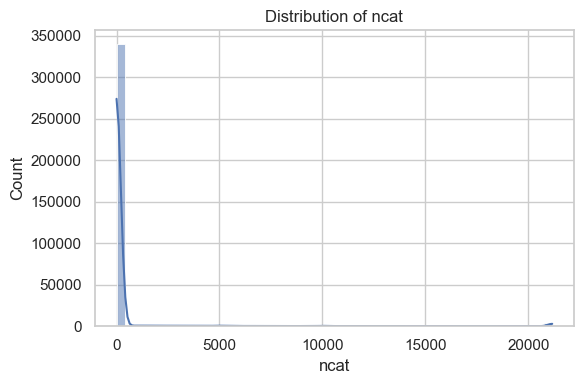

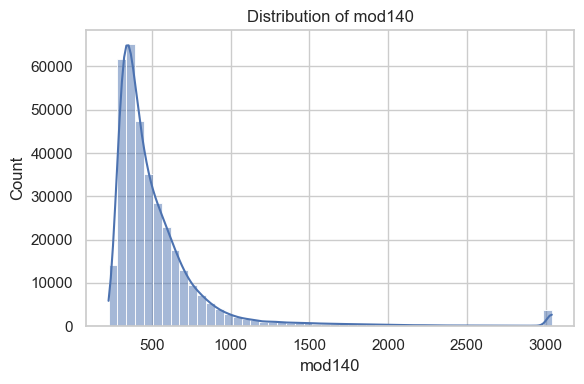

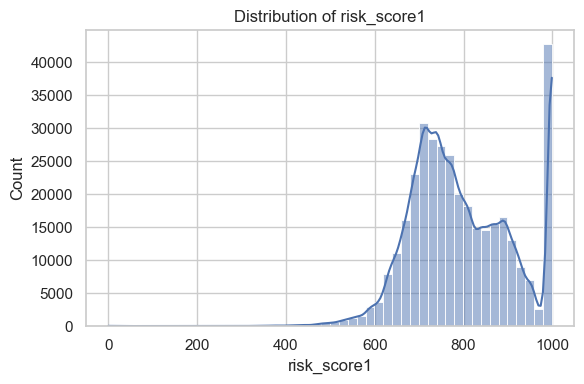

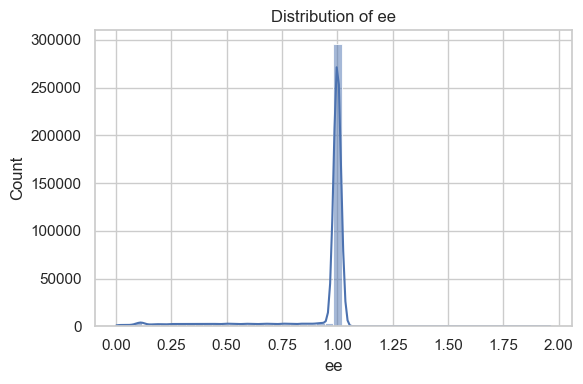

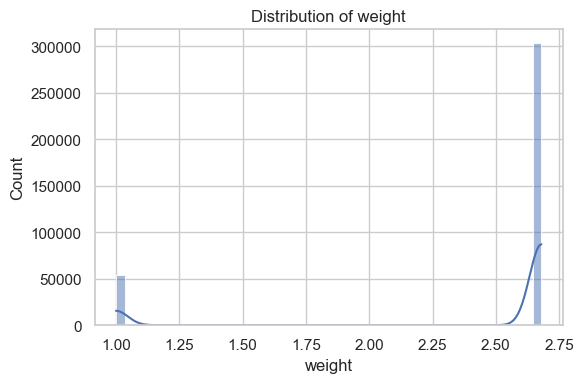

In [20]:
# Numeric: distribution plots (8+ features)
import matplotlib.pyplot as plt
import seaborn as sns

# Key continuous numeric variables from the baseline dataset
plot_cols = [
    "ncat",
    "mod140",
    "risk_score1",
    "ee",
    "weight"
]

for col in plot_cols:

    if col not in df.columns:
        continue

    plt.figure(figsize=(6,4))

    plot_data = df[col].dropna()

    # Clip extreme tails for highly skewed variables
    if plot_data.skew() > 5:
        upper = plot_data.quantile(0.99)
        plot_data = plot_data.clip(upper=upper)

    sns.histplot(plot_data, bins=50, kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

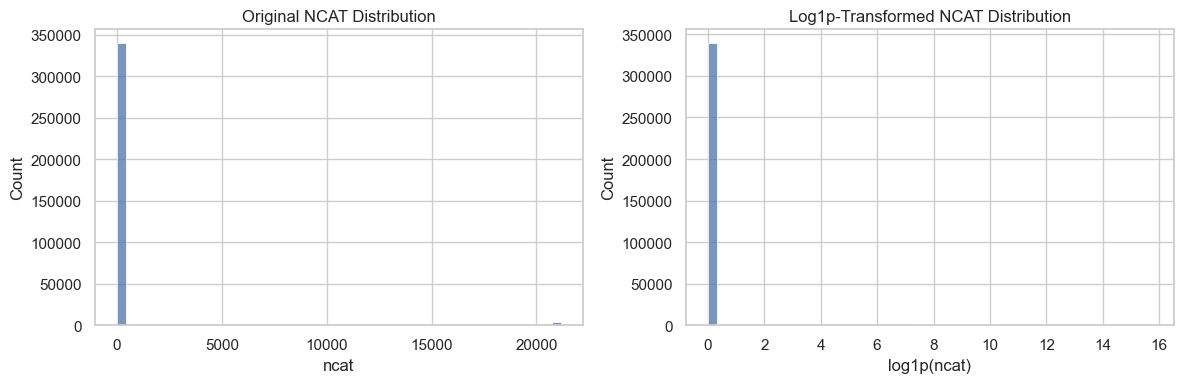

In [22]:
# Numeric: transformation candidates (before/after)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory transformation for highly skewed loss variable
df["log_ncat"] = np.log1p(df["ncat"])

# Clip extreme tail of raw NCAT for visualization only
original_ncat = df["ncat"].clip(
    upper=df["ncat"].quantile(0.99)
)

# Before vs after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
sns.histplot(original_ncat, bins=50, ax=axes[0])

axes[0].set_title("Original NCAT Distribution")
axes[0].set_xlabel("ncat")
axes[0].set_ylabel("Count")

# Log-transformed distribution
sns.histplot(df["log_ncat"], bins=50, ax=axes[1])

axes[1].set_title("Log1p-Transformed NCAT Distribution")
axes[1].set_xlabel("log1p(ncat)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The ncat variable shows extreme right-skewness and a large concentration of zero-valued observations, which is typical for insurance loss data. A log1p transformation was explored to reduce the influence of extreme losses and improve interpretability of the distribution.

In [24]:
# Categorical: cardinality, frequency tables, rare-level audit
# Convert categorical-like numeric variables

df["state"] = df["state"].astype("category")

df["zip"] = df["zip"].astype(str)
df["zip4"] = df["zip4"].astype(str)

df["vendor_year"] = df["vendor_year"].astype("category")
df["mod140_year"] = df["mod140_year"].astype("category")

# Categorical variables
cat_cols = [
    "state",
    "zip",
    "zip4",
    "vendor_year",
    "mod140_year"
]

# Cardinality audit
cardinality_df = pd.DataFrame({
    "feature": cat_cols,
    "dtype": [df[col].dtype for col in cat_cols],
    "n_unique": [df[col].nunique() for col in cat_cols]
})

cardinality_df.sort_values(by="n_unique", ascending=False)


,feature,dtype,n_unique
2,zip4,object,7929
1,zip,object,4037
4,mod140_year,category,8
3,vendor_year,category,7
0,state,category,6


In [25]:
for col in ["state", "vendor_year", "mod140_year"]:

    print(f"\nFrequency table for {col}")

    display(
        df[col]
        .value_counts(normalize=True)
        .rename("proportion")
        .to_frame()
    )
    


Frequency table for state


,proportion
state,
NJ,0.291608
MA,0.238677
NY,0.174146
PA,0.150563
CT,0.107039
NH,0.037966



Frequency table for vendor_year


,proportion
vendor_year,
2021,0.193529
2022,0.186667
2023,0.169332
2020,0.169312
2024,0.139370
2019,0.110398
2018,0.031393



Frequency table for mod140_year


,proportion
mod140_year,
2022,0.184833
2023,0.183604
2024,0.170298
2021,0.168733
2025,0.153076
2020,0.108295
2019,0.027582
2018,0.003579


- state exhibits low cardinality with a relatively balanced distribution across the six operating states.
- zip and zip4 show extremely high cardinality and primarily function as geographic identifiers rather than traditional categorical variables.
- vendor_year and mod140_year display reasonable temporal coverage across multiple policy years with no severe imbalance observed.
- High-cardinality geographic variables may require grouping or alternative encoding strategies during downstream modeling.

### Stage 5 — Interpretation

*Which features need transformation? Which categoricals need rare-level grouping? Any "numeric-looking" categoricals you reclassified?*

- ncat: transformation 
- zip/ zip4 : rare-level grouping 
- zip, zip4, vendor_year, mod140_year : numeric-looking categorical 

---

## Stage 6 — Target Analysis  *(10 pts)*

**Classification target:**
- Class frequencies and proportions; bar chart.
- Imbalance ratio.
- Recommended response (none / class weights / resampling / threshold tuning), **tied to the metric chosen in Stage 1**.
- Stratification implications for your Stage 10 split.

**Regression target:**
- Distribution, summary statistics, skew, kurtosis.
- Outlier and zero-inflation check.
- Transformation evaluation (e.g., log-target) with before/after plots; recommend whether to model on the transformed scale.

**Both:**
- If a temporal axis exists, plot target over time and comment on drift, seasonality, or regime change.

Target Summary Statistics


count    3.564480e+05
mean     1.185942e+03
std      2.226772e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.864000e+06
Name: ncat, dtype: float64


Skewness: 117.07
Kurtosis: 28029.13
Zero-loss proportion: 95.13%


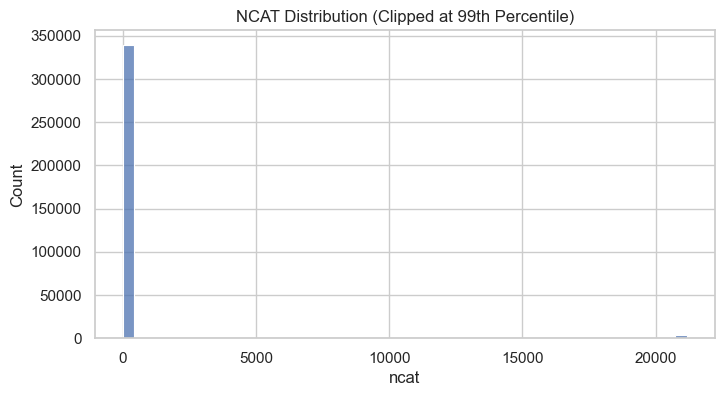

In [26]:
# Target distribution
target = df["ncat"]

print("Target Summary Statistics")
display(target.describe())

print(f"\nSkewness: {target.skew():.2f}")
print(f"Kurtosis: {target.kurtosis():.2f}")

zero_pct = (target == 0).mean() * 100
print(f"Zero-loss proportion: {zero_pct:.2f}%")

# Distribution plot
plt.figure(figsize=(8,4))

sns.histplot(
    target.clip(upper=target.quantile(0.99)),
    bins=50
)

plt.title("NCAT Distribution (Clipped at 99th Percentile)")
plt.xlabel("ncat")
plt.ylabel("Count")

plt.show()

- The target variable (`ncat`) is extremely zero-inflated, with approximately 95% of observations having no loss.
- The distribution is heavily right-skewed with extreme tail behavior driven by a small number of catastrophic losses.
- The target characteristics are consistent with typical insurance loss data and support the use of Tweedie-style modeling approaches.
- A log-style transformation was explored for visualization purposes, though the final modeling strategy may instead rely on Tweedie GLM with exposure offset.

Zero-loss proportion: 95.13%
Skewness: 117.07
Kurtosis: 28029.13


/var/folders/tg/ntvm9wc94h937xqtzftck9xc0000gn/T/ipykernel_21728/2035134621.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("vendor_year")["ncat"]


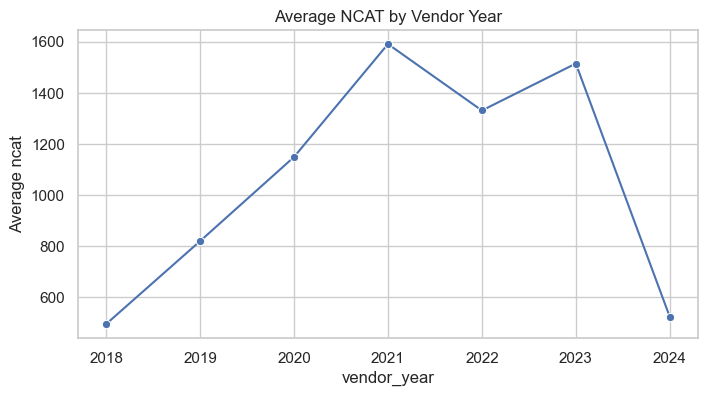

In [27]:
# Imbalance / skew metrics + (if applicable) target-over-time plot
# Imbalance / skew metrics + target-over-time plot

# Zero-loss proportion
zero_pct = (df["ncat"] == 0).mean() * 100

print(f"Zero-loss proportion: {zero_pct:.2f}%")
print(f"Skewness: {df['ncat'].skew():.2f}")
print(f"Kurtosis: {df['ncat'].kurtosis():.2f}")

# Average target over time
target_by_year = (
    df.groupby("vendor_year")["ncat"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(8,4))

sns.lineplot(
    data=target_by_year,
    x="vendor_year",
    y="ncat",
    marker="o"
)

plt.title("Average NCAT by Vendor Year")
plt.xlabel("vendor_year")
plt.ylabel("Average ncat")

plt.show()

- The target variable is highly zero-inflated, with approximately 95% zero-loss observations.
- Extreme skewness and kurtosis indicate substantial heavy-tail behavior driven by catastrophic losses.
- Average NCAT levels vary across policy years, suggesting potential temporal drift and changing loss environments over time.
- The sharp decline observed in 2024 may reflect incomplete exposure maturity or partial development of recent claims data.

### Stage 6 — Interpretation

*State your recommended response (class weights / resampling / target transform / etc.) and tie it back to the metric chosen in Stage 1.*

- The target variable exhibits extreme zero-inflation and heavy-tail behavior, which is consistent with standard insurance loss data.
- Because the project objective is pure premium prediction rather than binary classification, resampling or class-weighting approaches are not recommended at this stage.
- A Tweedie-based modeling framework is more appropriate due to its ability to naturally accommodate a mixture of zero-loss and continuous positive-loss outcomes.
- A log-style transformation was explored for visualization and diagnostic purposes; however, the final modeling strategy will likely rely on Tweedie GLM with a log link and exposure offset rather than directly modeling a transformed target.
- Temporal variation across policy years suggests that out-of-time validation should be incorporated to evaluate model stability and generalization performance.
- These recommendations align with the Stage 1 objective of improving ranking performance and calibration quality for pure premium estimation.

---

## Stage 7 — Bivariate Signals vs. Target  *(12 pts)*

For **every retained feature**, quantify its bivariate relationship with the target using a test appropriate to the variable-type pair.

| Feature type | Classification target | Regression target |
|---|---|---|
| Continuous / count | Point-biserial *r*; ANOVA F or Kruskal-Wallis H; AUC of feature alone | Pearson *r*, Spearman *ρ* (report both) |
| Ordinal | Mann-Whitney / Kruskal-Wallis; Spearman *ρ* | Spearman *ρ*, Kendall *τ* |
| Nominal | Chi-square + **Cramér's V**; target rate by level | One-way ANOVA + **η²**; group means with CIs |
| Binary | Two-proportion z; difference in target rate | t-test or Mann-Whitney; **Cohen's *d*** |

**Required output:**
- A ranked table of all features with: test used, statistic, p-value, **effect size**, one-line interpretation.
- At least 6 illustrative plots (violin/box-by-class, target-rate-by-bin, scatter with LOWESS).
- Explicit acknowledgement of multiple-comparison risk (Bonferroni, Benjamini-Hochberg, or a stated screening caveat).

> A statistically significant *p*-value with a trivial effect size is **not a signal**. Effect size is required.

In [28]:
# Bivariate tests — numeric features vs target
from scipy.stats import pearsonr, spearmanr
import pandas as pd

# Numeric features to test against target
numeric_features = [
    "mod140",
    "risk_score1",
    "ee"
]

target_col = "ncat"

numeric_results = []

for col in numeric_features:
    
    if col not in df.columns:
        continue
    
    temp = df[[col, target_col]].dropna()
    
    pearson_corr, pearson_p = pearsonr(temp[col], temp[target_col])
    spearman_corr, spearman_p = spearmanr(temp[col], temp[target_col])
    
    numeric_results.append({
        "feature": col,
        "test": "Pearson / Spearman correlation",
        "pearson_r": pearson_corr,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_corr,
        "spearman_p": spearman_p,
        "interpretation": "Bivariate association with NCAT"
    })

numeric_results_df = pd.DataFrame(numeric_results)

numeric_results_df.sort_values(
    by="spearman_rho",
    ascending=False
)

,feature,test,pearson_r,pearson_p,spearman_rho,spearman_p,interpretation
0,mod140,Pearson / Spearman correlation,0.120957,0.000000e+00,0.078172,0.000000e+00,Bivariate association with NCAT
2,ee,Pearson / Spearman correlation,0.014085,4.116792e-17,0.037067,1.365839e-108,Bivariate association with NCAT
1,risk_score1,Pearson / Spearman correlation,-0.010582,2.645484e-10,-0.046358,8.656279e-169,Bivariate association with NCAT


- `mod140` shows the strongest positive association with `ncat`, which is expected since it represents the current baseline pure premium prediction.
- `ee` exhibits only a weak relationship with the target despite statistical significance.
- `risk_score1` shows a very small negative association with `ncat`, suggesting limited standalone predictive power.
- Due to the very large sample size, statistically significant p-values should be interpreted together with effect sizes rather than in isolation.

In [29]:
# Bivariate tests — categorical features vs target (Cramér's V / η²)
from scipy.stats import f_oneway
import numpy as np

# Categorical features
categorical_features = [
    "state",
    "vendor_year",
    "mod140_year"
]

categorical_results = []

for col in categorical_features:
    
    temp = df[[col, "ncat"]].dropna()
    
    # Groups for ANOVA
    groups = [
        group["ncat"].values
        for _, group in temp.groupby(col)
    ]
    
    # ANOVA
    f_stat, p_value = f_oneway(*groups)
    
    # Eta-squared effect size
    grand_mean = temp["ncat"].mean()
    
    ss_between = sum(
        len(group) * (group.mean() - grand_mean) ** 2
        for _, group in temp.groupby(col)["ncat"]
    )
    
    ss_total = sum(
        (temp["ncat"] - grand_mean) ** 2
    )
    
    eta_squared = ss_between / ss_total
    
    categorical_results.append({
        "feature": col,
        "test": "ANOVA",
        "f_stat": f_stat,
        "p_value": p_value,
        "eta_squared": eta_squared,
        "interpretation": "Difference in average NCAT across groups"
    })

categorical_results_df = pd.DataFrame(categorical_results)

categorical_results_df.sort_values(
    by="eta_squared",
    ascending=False
)

/var/folders/tg/ntvm9wc94h937xqtzftck9xc0000gn/T/ipykernel_21728/2114844556.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in temp.groupby(col)
/var/folders/tg/ntvm9wc94h937xqtzftck9xc0000gn/T/ipykernel_21728/2114844556.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in temp.groupby(col)["ncat"]
/var/folders/tg/ntvm9wc94h937xqtzftck9xc0000gn/T/ipykernel_21728/2114844556.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

,feature,test,f_stat,p_value,eta_squared,interpretation
1,vendor_year,ANOVA,17.412967,2.934894e-20,0.000293,Difference in average NCAT across groups
2,mod140_year,ANOVA,14.129634,1.824717e-18,0.000278,Difference in average NCAT across groups
0,state,ANOVA,11.332888,5.941831e-11,0.000159,Difference in average NCAT across groups


- Although `state`, `vendor_year`, and `mod140_year` are statistically significant in ANOVA tests, all effect sizes (η²) are extremely small.
- This suggests that differences in average `ncat` across these groups are practically limited despite the large sample size.
- The results reinforce the importance of evaluating effect sizes alongside p-values in large-scale insurance datasets.
- Temporal variables still remain operationally important for validation and drift monitoring even if their standalone explanatory power is small.

In [30]:
# Ranked feature table: feature | test | statistic | p | effect size | interpretation
# Ranked feature table

# Numeric feature table
numeric_ranked = numeric_results_df.copy()

numeric_ranked["statistic"] = numeric_ranked["spearman_rho"]
numeric_ranked["p_value"] = numeric_ranked["spearman_p"]
numeric_ranked["effect_size"] = numeric_ranked["spearman_rho"]

numeric_ranked = numeric_ranked[
    [
        "feature",
        "test",
        "statistic",
        "p_value",
        "effect_size",
        "interpretation"
    ]
]

# Categorical feature table
categorical_ranked = categorical_results_df.copy()

categorical_ranked["statistic"] = categorical_ranked["f_stat"]
categorical_ranked["effect_size"] = categorical_ranked["eta_squared"]

categorical_ranked = categorical_ranked[
    [
        "feature",
        "test",
        "statistic",
        "p_value",
        "effect_size",
        "interpretation"
    ]
]

# Combine
ranked_features = pd.concat(
    [numeric_ranked, categorical_ranked],
    ignore_index=True
)

# Sort by absolute effect size
ranked_features["abs_effect"] = ranked_features["effect_size"].abs()

ranked_features = ranked_features.sort_values(
    by="abs_effect",
    ascending=False
)

ranked_features.drop(columns="abs_effect")

,feature,test,statistic,p_value,effect_size,interpretation
0,mod140,Pearson / Spearman correlation,0.078172,0.000000e+00,0.078172,Bivariate association with NCAT
1,risk_score1,Pearson / Spearman correlation,-0.046358,8.656279e-169,-0.046358,Bivariate association with NCAT
2,ee,Pearson / Spearman correlation,0.037067,1.365839e-108,0.037067,Bivariate association with NCAT
4,vendor_year,ANOVA,17.412967,2.934894e-20,0.000293,Difference in average NCAT across groups
5,mod140_year,ANOVA,14.129634,1.824717e-18,0.000278,Difference in average NCAT across groups
3,state,ANOVA,11.332888,5.941831e-11,0.000159,Difference in average NCAT across groups


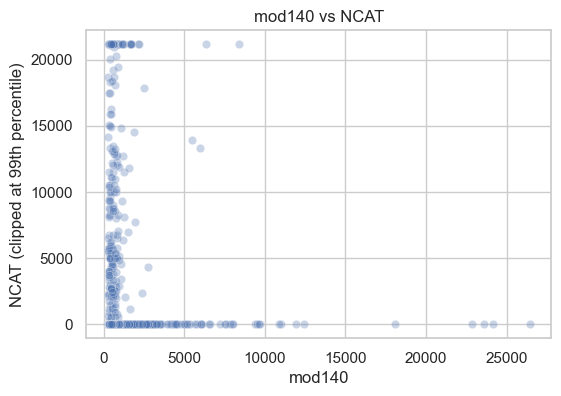

Takeaway: mod140 shows the strongest positive relationship with NCAT among the numeric baseline features.


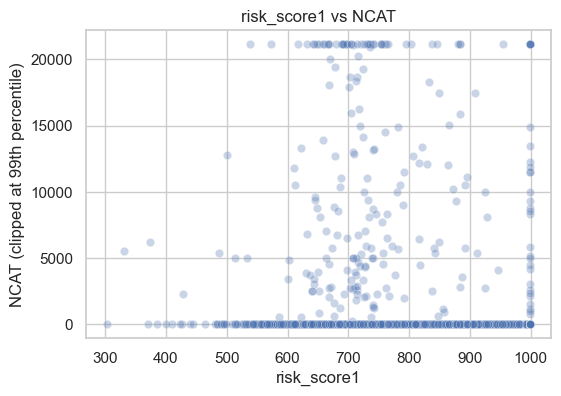

Takeaway: risk_score1 shows limited standalone relationship with NCAT.


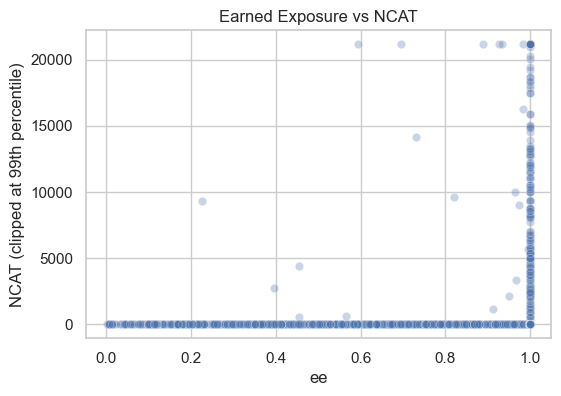

Takeaway: ee shows a weak direct relationship with NCAT, but remains important as an exposure offset in modeling.


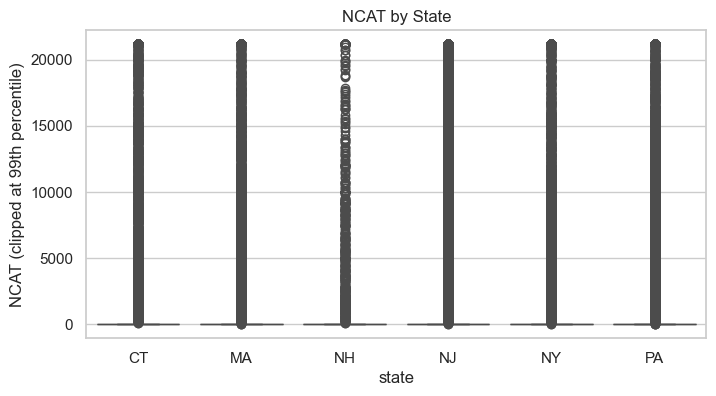

Takeaway: State-level differences exist, but ANOVA effect sizes suggest limited standalone explanatory power.


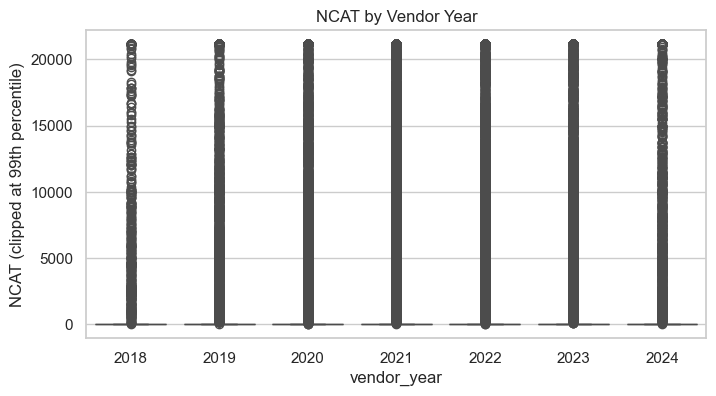

Takeaway: Year-level variation suggests temporal monitoring is important, even if standalone effect size is small.


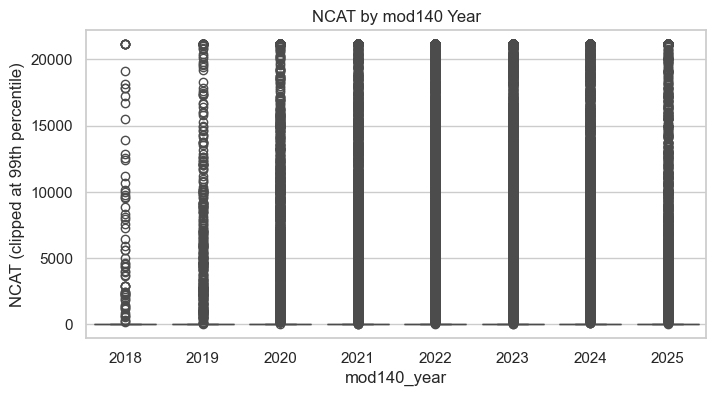

Takeaway: mod140_year provides temporal context for validation and drift analysis rather than strong standalone signal.


In [31]:
# Illustrative plots (6+) with takeaway captions

plot_df = df.copy()
plot_df["ncat_clipped"] = plot_df["ncat"].clip(
    upper=plot_df["ncat"].quantile(0.99)
)

# 1. mod140 vs ncat
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=plot_df.sample(5000, random_state=42),
    x="mod140",
    y="ncat_clipped",
    alpha=0.3
)
plt.title("mod140 vs NCAT")
plt.xlabel("mod140")
plt.ylabel("NCAT (clipped at 99th percentile)")
plt.show()

print("Takeaway: mod140 shows the strongest positive relationship with NCAT among the numeric baseline features.")

# 2. risk_score1 vs ncat
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=plot_df.sample(5000, random_state=42),
    x="risk_score1",
    y="ncat_clipped",
    alpha=0.3
)
plt.title("risk_score1 vs NCAT")
plt.xlabel("risk_score1")
plt.ylabel("NCAT (clipped at 99th percentile)")
plt.show()

print("Takeaway: risk_score1 shows limited standalone relationship with NCAT.")

# 3. ee vs ncat
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=plot_df.sample(5000, random_state=42),
    x="ee",
    y="ncat_clipped",
    alpha=0.3
)
plt.title("Earned Exposure vs NCAT")
plt.xlabel("ee")
plt.ylabel("NCAT (clipped at 99th percentile)")
plt.show()

print("Takeaway: ee shows a weak direct relationship with NCAT, but remains important as an exposure offset in modeling.")

# 4. state vs ncat
plt.figure(figsize=(8,4))
sns.boxplot(
    data=plot_df,
    x="state",
    y="ncat_clipped"
)
plt.title("NCAT by State")
plt.xlabel("state")
plt.ylabel("NCAT (clipped at 99th percentile)")
plt.show()

print("Takeaway: State-level differences exist, but ANOVA effect sizes suggest limited standalone explanatory power.")

# 5. vendor_year vs ncat
plt.figure(figsize=(8,4))
sns.boxplot(
    data=plot_df,
    x="vendor_year",
    y="ncat_clipped"
)
plt.title("NCAT by Vendor Year")
plt.xlabel("vendor_year")
plt.ylabel("NCAT (clipped at 99th percentile)")
plt.show()

print("Takeaway: Year-level variation suggests temporal monitoring is important, even if standalone effect size is small.")

# 6. mod140_year vs ncat
plt.figure(figsize=(8,4))
sns.boxplot(
    data=plot_df,
    x="mod140_year",
    y="ncat_clipped"
)
plt.title("NCAT by mod140 Year")
plt.xlabel("mod140_year")
plt.ylabel("NCAT (clipped at 99th percentile)")
plt.show()

print("Takeaway: mod140_year provides temporal context for validation and drift analysis rather than strong standalone signal.")

### Stage 7 — Interpretation

*Which features show meaningful effect sizes (not just significance)? Name at least one significant-but-trivial feature and one borderline-significant-but-practically-interesting feature. Address multiple-comparison risk.*

---

## Stage 8 — Multivariate Structure  *(12 pts)*

**Produce:**
- **Pearson and Spearman** correlation matrices for numeric features (heatmaps). Interpret disagreements (linear vs. monotonic).
- Multicollinearity assessment via **VIF** (or condition number) on the candidate numeric feature set; flag VIF > 10.
- Pairplots or facetted scatter for the top 6–8 features identified in Stage 7, colored/grouped by target.
- **Multivariate outlier detection**: Isolation Forest *or* Mahalanobis distance on the numeric feature set. Investigate the top 1% — errors, edge cases, or a meaningful subpopulation?
- *Encouraged but optional:* PCA scree plot and 2-component projection colored by target.

In [ ]:
# Pearson + Spearman correlation matrices; comment on disagreements


In [ ]:
# VIF / multicollinearity assessment


In [ ]:
# Pairplots / facets on top features by target


In [ ]:
# Multivariate outlier detection (Isolation Forest or Mahalanobis) + top-1% investigation


### Stage 8 — Interpretation

*Where do Pearson and Spearman disagree, and what does that imply? Which VIF clusters need consolidation? What did the multivariate outliers turn out to be?*

---

## Stage 9 — Mutual Information & Leakage Screen  *(12 pts)*

### 9a. Mutual Information
- Compute MI between every feature and the target using the **correct** sklearn estimator (`mutual_info_classif` for classification, `mutual_info_regression` for regression).
- Encode categoricals appropriately and pass `discrete_features` correctly.
- Rank features by MI; produce a horizontal bar chart of the top 20.
- Compare the MI ranking with Stage 7's linear-association ranking. **Identify and discuss ≥ 3 features where the two rankings disagree** — this is where non-linear signal lives.

### 9b. Leakage Screen (graded heavily)
For every feature in the top quartile of MI *or* top quartile of bivariate effect size, answer **in writing** for each feature:
1. Is this feature available **at the time of prediction**, or only after the target is realized?
2. Is it derived from, or a near-restatement of, the target?
3. Is it an identifier, timestamp, or post-event flag?
4. Does it look "too good to be true" given domain context?

Any feature failing 1–4 must be flagged **leakage-suspect** in your Data Card and excluded from the modeling set.

### 9c. Tree-based Sanity Check (Optional)
Train a single tree-based "EDA model" (e.g., `RandomForestClassifier`/`RandomForestRegressor`) **purely as an importance probe**. Report **permutation importance** on a held-out split. State the caveat: this is *not* model selection.

In [ ]:
# 9a — Mutual information (correct estimator, encoded categoricals, discrete_features mask)


In [ ]:
# 9a — Top-20 MI bar chart + comparison vs Stage 7 linear ranking


### 9b — Leakage Screen (per-feature)

*For every top-quartile feature, answer the four leakage questions and decide: keep / flag / drop.*

| Feature | Q1 (available at prediction time?) | Q2 (target-derived?) | Q3 (ID/timestamp/post-event?) | Q4 (too good to be true?) | Decision |
|---|---|---|---|---|---|
|  |  |  |  |  |  |

In [ ]:
# 9c — Tree-based sanity check + permutation importance on held-out split
# REMINDER: this is a non-linear sanity check on the MI ranking, NOT model selection.


### Stage 9 — Interpretation

*Where do MI and linear correlation disagree, and what is the non-linear story? Which features did you flag as leakage-suspect, and on what evidence? Does the permutation-importance ranking support or challenge your MI ranking?*

---

## Stage 10 — SL-Readiness Deliverables  *(15 pts)*

Produce **all four** sub-deliverables. The Data Card (10a) should also be exported as a standalone `<lastname>_<firstname>_data_card.md`.

### 10a — Data Card / Feature Dictionary

One row per feature. Internally consistent with Stages 2–9.

| Feature | Semantic type | % missing | Univariate notes | Bivariate signal (stat, effect size) | MI | Multicoll. flag | Leakage flag | Recommended treatment | Encoding | Scaling | Keep / Drop |
|---|---|---|---|---|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |  |  |  |  |  |

### 10b — Train / Validation / Test Split Recommendation

Choose **one** and justify against this dataset's specific risks:
- ☐ Random
- ☐ Stratified (by target)
- ☐ Grouped (specify grouping key: ____)
- ☐ Time-based (specify cutoff: ____)
- ☐ Nested

**Fractions:** train ___ / val ___ / test ___

**Justification (address leakage between splits, target stratification, group leakage, temporal validity):**

### 10c — Preprocessing Pipeline Sketch

Map each kept feature to its transformer chain. Specific enough that someone else could implement it as a `sklearn.pipeline.Pipeline` / `ColumnTransformer`. Mark fit-on-train-only operations clearly.

| Feature | Imputation | Transform | Encoding | Scaling | Notes (fit-on-train-only?) |
|---|---|---|---|---|---|
|  |  |  |  |  |  |

### 10d — Top-10 Candidate Predictors + Known Risks

**Top 10 (with evidence cited from Stages 7 + 9 + 8):**
1. 
2. 
3. 
4. 
5. 
6. 
7. 
8. 
9. 
10. 

**Known Risks register:**
- *Leakage suspects retained or removed:*
- *Multicollinearity clusters:*
- *Missingness assumptions:*
- *Drift / temporal-stability concerns:*
- *Fairness-sensitive features and proxies:*
- *Other:*

---

## Submission Checklist

- [ ] Notebook executes top-to-bottom on a fresh kernel.
- [ ] Random seed set and documented.
- [ ] All 10 stages have numbered headers.
- [ ] Data Card exported as both notebook table and standalone `.md`.
- [ ] Readiness Memo PDF (3–5 pages) addresses: problem framing, dataset health, top signals, leakage / risk register, split & preprocessing recommendation, open questions.
- [ ] Every p-value paired with an effect size.
- [ ] Every plot has title, axis labels, and a caption.
- [ ] Leakage screen explicit and per-feature for every top-quartile feature.
- [ ] Train / val / test split strategy stated and justified.
- [ ] Preprocessing pipeline sketch present.
- [ ] Files named per convention; submitted as a single zipped folder.